# Audio Codec Inspection Pipeline

## Setup and Imports

In [13]:
using Flux
using JLD2
using Random
using Plots
using Statistics
using Printf
using JSON
using Plots


include("src/data.jl")
include("src/preprocess.jl")
include("src/quantizer.jl")
include("src/model.jl")
include("src/metric_calc.jl")

using .Data
using .Preprocess
using .Quantizer
using .Model
using .Metric_Calc

## Load Model

In [2]:
model_path = "best_model.bson"
model = JLD2.jldopen(model_path, "r") do file
    file["model"]
end
model = model |> cpu
Flux.testmode!(model)
println("Model loaded successfully and moved to CPU")

Model loaded successfully and moved to CPU


## Load Random Test Audio

In [3]:
audio_files = Data.list_librispeech_flac("."; split="test-clean")
random_idx = rand(1:length(audio_files))
audio_path = audio_files[random_idx]
sample_audio = Data.load_audio(audio_path)
sample_id = basename(dirname(audio_path)) * "/" * basename(audio_path)

println("Loaded sample: ", sample_id)
println("Audio length: ", length(sample_audio), " samples")
println("Duration: ", length(sample_audio) / Data.SAMPLE_RATE, " seconds")

Loaded sample: 131720/2300-131720-0000.flac
Audio length: 81280 samples
Duration: 5.08 seconds


## Input Mel-Spectrogram (Normalized)

Mel fixed length: 16000
Mel flat shape: (16000, 1, 1)
Mel 2D shape: (80, 200)
Mel range: [-23.02585, 3.436895]


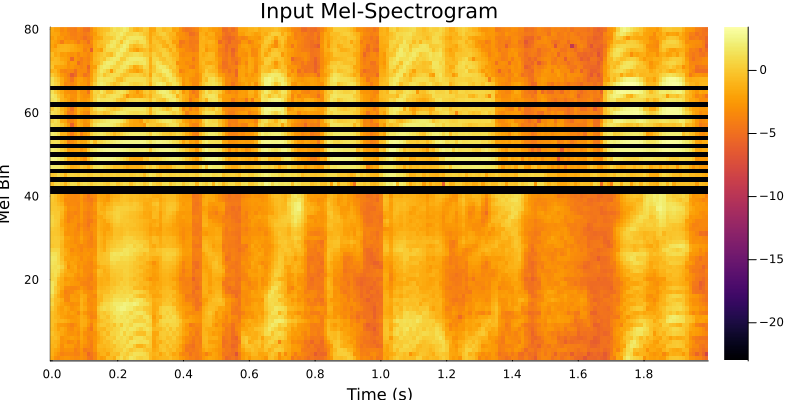

In [4]:
target_length = 16000
mel = Data.logmel(sample_audio)
mel_fixed = Preprocess.fix_length_flat(mel, target_length)
mel_flat = reshape(mel_fixed, :, 1, 1)

println("Mel fixed length: ", length(mel_fixed))
println("Mel flat shape: ", size(mel_flat))

n_mels = Data.N_MELS
n_frames_fixed = div(target_length, n_mels)

mel_2d = reshape(mel_fixed, n_mels, n_frames_fixed)
println("Mel 2D shape: ", size(mel_2d))
println("Mel range: [", minimum(mel_2d), ", ", maximum(mel_2d), "]")

time_axis = (0:n_frames_fixed-1) .* Data.HOP_LENGTH ./ Data.SAMPLE_RATE

heatmap(mel_2d, 
    title="Input Mel-Spectrogram",
    xlabel="Time (s)",
    ylabel="Mel Bin",
    colorbar=true,
    aspect_ratio=:auto,
    xticks=(1:max(1,n_frames_fixed÷10):n_frames_fixed, round.(time_axis[1:max(1,n_frames_fixed÷10):n_frames_fixed], digits=2)),
    size=(800, 400))

## Encode and Quantize

Latent shape: (1, 100, 96)
Quantized shape: (1, 100, 96)
Indices shape: (100,)
Indices range: [0.0, 0.0]
Quantized latent for visualization: (100, 96)


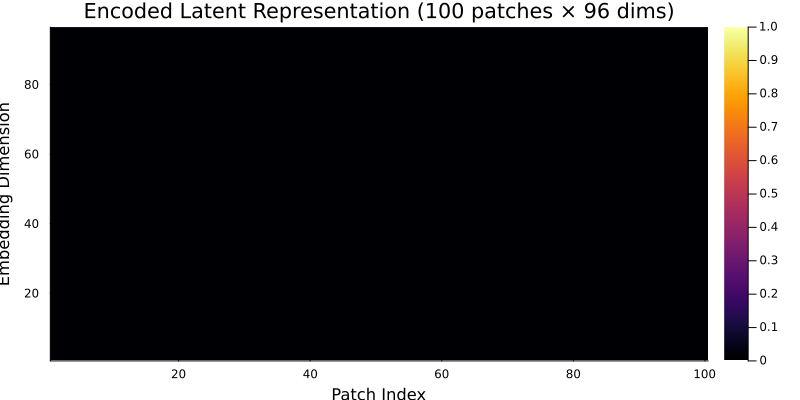

In [5]:
latent = model.encoder(mel_flat)
quantized, indices = model.quantizer(latent)

println("Latent shape: ", size(latent))
println("Quantized shape: ", size(quantized))
println("Indices shape: ", size(indices))
println("Indices range: [", minimum(indices), ", ", maximum(indices), "]")

quantized_2d = reshape(quantized[1, :, :], size(quantized, 2), size(quantized, 3))
println("Quantized latent for visualization: ", size(quantized_2d))

heatmap(quantized_2d',
    title="Encoded Latent Representation (100 patches × 96 dims)",
    xlabel="Patch Index",
    ylabel="Embedding Dimension",
    colorbar=true,
    aspect_ratio=:auto,
    size=(800, 400))

Reconstructed mel shape: (80, 200)
Reconstructed mel range: [-14.168287, -1.5485071]


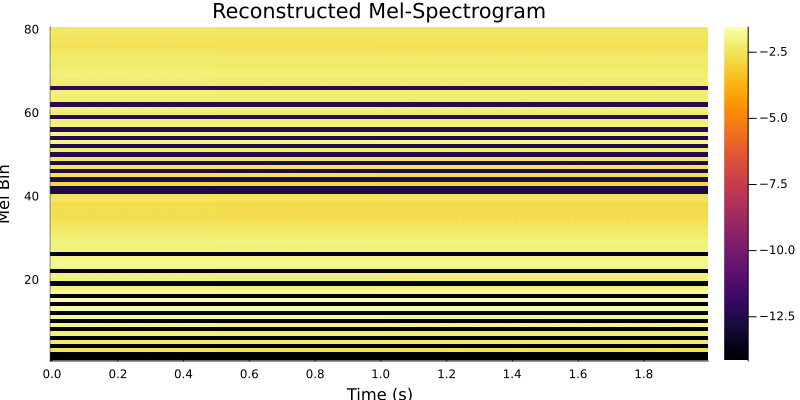

In [6]:
recon_flat = model.decoder(quantized)
recon_2d = reshape(recon_flat[:, 1, 1], n_mels, n_frames_fixed)

println("Reconstructed mel shape: ", size(recon_2d))
println("Reconstructed mel range: [", minimum(recon_2d), ", ", maximum(recon_2d), "]")

heatmap(recon_2d,
    title="Reconstructed Mel-Spectrogram",
    xlabel="Time (s)",
    ylabel="Mel Bin",
    colorbar=true,
    aspect_ratio=:auto,
    xticks=(1:max(1,n_frames_fixed÷10):n_frames_fixed, round.(time_axis[1:max(1,n_frames_fixed÷10):n_frames_fixed], digits=2)),
    size=(800, 400))

## Comparison: Input vs Encoded vs Reconstructed

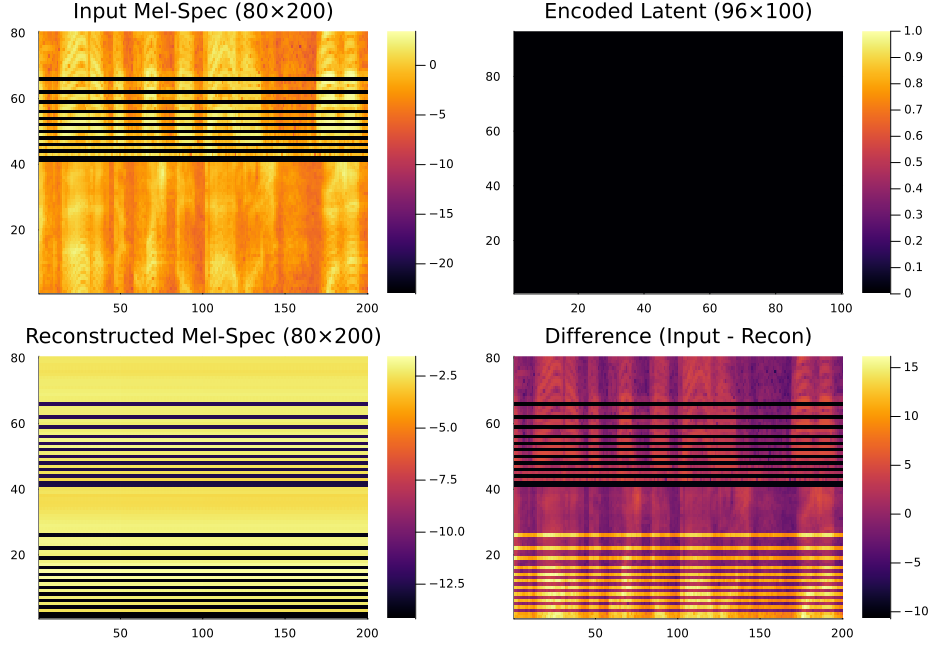

In [7]:
p1 = heatmap(mel_2d, title="Input Mel-Spec (80×200)", colorbar=true, size=(450, 300))
p2 = heatmap(quantized_2d', title="Encoded Latent (96×100)", colorbar=true, size=(450, 300))
p3 = heatmap(recon_2d, title="Reconstructed Mel-Spec (80×200)", colorbar=true, size=(450, 300))
p4 = heatmap(mel_2d .- recon_2d, title="Difference (Input - Recon)", colorbar=true, size=(450, 300))

plot(p1, p2, p3, p4, layout=(2, 2), size=(950, 650))

## Evaluation Metrics

In [8]:
metric_result = Metric_Calc.evaluate_model(model, sample_audio, sample_id)

println("\n" * "="^70)
println("EVALUATION METRICS")
println("="^70)
println("Sample ID: ", sample_id)
println()
@printf "Latency:       %.2f ms (threshold: < %.1f ms) %s\n" metric_result.latency Metric_Calc.LATENCY_THRESHOLD (metric_result.latency < Metric_Calc.LATENCY_THRESHOLD ? "PASS" : "FAIL")
@printf "Bitrate:       %.2f kbps (range: %.1f-%.1f kbps) %s\n" metric_result.bitrate Metric_Calc.BITRATE_MIN Metric_Calc.BITRATE_MAX (metric_result.bitrate >= Metric_Calc.BITRATE_MIN && metric_result.bitrate <= Metric_Calc.BITRATE_MAX ? "PASS" : "FAIL")
@printf "PESQ (approx): %.2f (threshold: > %.1f) %s\n" metric_result.pesq Metric_Calc.PESQ_THRESHOLD (metric_result.pesq > Metric_Calc.PESQ_THRESHOLD ? "PASS" : "FAIL")
@printf "STOI (approx): %.4f (threshold: > %.2f) %s\n" metric_result.stoi Metric_Calc.STOI_THRESHOLD (metric_result.stoi > Metric_Calc.STOI_THRESHOLD ? "PASS" : "FAIL")
println("="^70)


EVALUATION METRICS
Sample ID: 131720/2300-131720-0000.flac

Latency:       50.44 ms (threshold: < 20.0 ms) FAIL
Bitrate:       0.16 kbps (range: 8.0-16.0 kbps) FAIL
PESQ (approx): 4.32 (threshold: > 3.5) PASS
STOI (approx): 0.7929 (threshold: > 0.90) FAIL


## Waveform Comparison

In [9]:
orig = sample_audio
recon_audio = Data.griffin_lim(recon_2d)

min_len = min(length(orig), length(recon_audio))
orig = orig[1:min_len]
recon = recon_audio[1:min_len]

println("\n=== Waveform Stats ===")
println("Original waveform length: ", length(orig), " samples")
println("Reconstructed waveform length: ", length(recon), " samples")
println("Original amplitude range: [", minimum(orig), ", ", maximum(orig), "]")
println("Reconstructed amplitude range: [", minimum(recon), ", ", maximum(recon), "]")


=== Waveform Stats ===
Original waveform length: 31840 samples
Reconstructed waveform length: 31840 samples
Original amplitude range: [-0.5393677, 0.6768799]
Reconstructed amplitude range: [-0.026990833, 0.0291862]


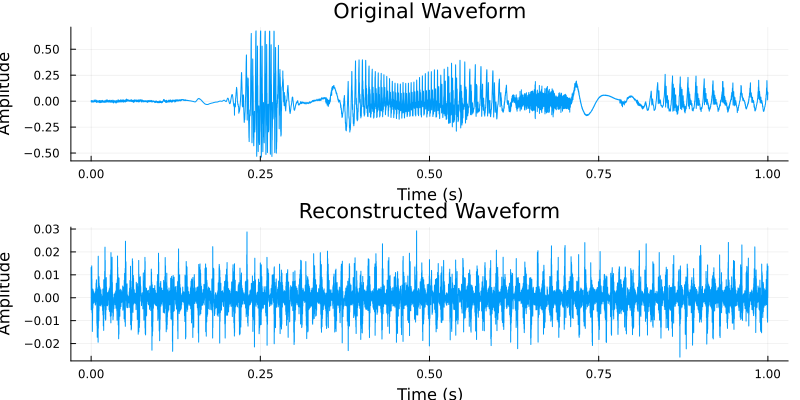

In [10]:
sample_points = min(16000, length(orig))
time_axis = (1:sample_points) ./ Data.SAMPLE_RATE

p1 = plot(time_axis, orig[1:sample_points], 
    title="Original Waveform", 
    xlabel="Time (s)", 
    ylabel="Amplitude",
    legend=false,
    size=(800, 200))

p2 = plot(time_axis, recon[1:sample_points], 
    title="Reconstructed Waveform",
    xlabel="Time (s)",
    ylabel="Amplitude",
    legend=false,
    size=(800, 200))

plot(p1, p2, layout=(2, 1), size=(800, 400))

## Save Audio Files for Playback

In [11]:
using WAV

orig_normalized = orig ./ maximum(abs.(orig))
recon_normalized = recon ./ maximum(abs.(recon))

wavwrite(orig_normalized, "input_audio.wav", Fs=Int(Data.SAMPLE_RATE))
wavwrite(recon_normalized, "reconstructed_audio.wav", Fs=Int(Data.SAMPLE_RATE))

println("Audio files saved:")
println("input_audio.wav (Original audio)")
println("reconstructed_audio.wav (Griffin-Lim from model output)")

Audio files saved:
input_audio.wav (Original audio)
reconstructed_audio.wav (Griffin-Lim from model output)


## Playback Audio in Notebook

In [12]:
using Base64

function audio_player(filename::String, label::String)
    audio_data = read(filename)
    b64_audio = base64encode(audio_data)
    html = """
    <div style="margin: 10px 0;">
        <strong>$label</strong><br/>
        <audio controls>
            <source src="data:audio/wav;base64,$b64_audio" type="audio/wav">
            Your browser does not support the audio element.
        </audio>
    </div>
    """
    display("text/html", html)
end

audio_player("input_audio.wav", "Input Audio (Original)")
audio_player("reconstructed_audio.wav", "Reconstructed Audio (Model Output → Griffin-Lim)")

Input Audio (Original) 
 
 
 Your browser does not support the audio element.

Reconstructed Audio (Model Output → Griffin-Lim) 
 
 
 Your browser does not support the audio element.

## Training Loss Plot

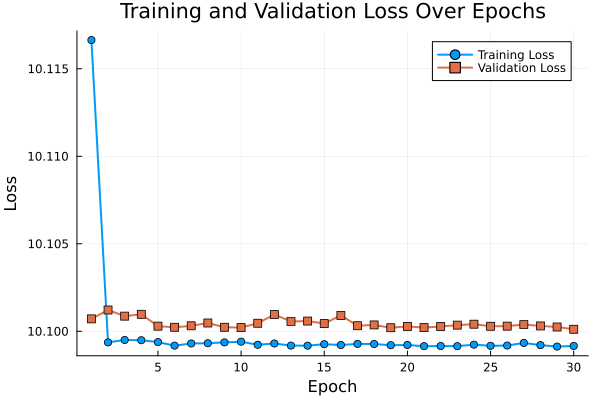

In [14]:
losses_data = JSON.parsefile("losses.json")
epochs = sort(parse.(Int, keys(losses_data)))
train_losses = [losses_data[string(epoch)]["train"] for epoch in epochs]
val_losses = [losses_data[string(epoch)]["val"] for epoch in epochs]

plot(epochs, train_losses, label="Training Loss", linewidth=2, marker=:circle)
plot!(epochs, val_losses, label="Validation Loss", linewidth=2, marker=:square)
xlabel!("Epoch")
ylabel!("Loss")
title!("Training and Validation Loss Over Epochs")
plot!(legend=:topright, grid=true)